# 01 — Exploratory Data Analysis
**Course:** MCS5343 · **Phase:** 1 · **Dataset:** IEEE-CIS Fraud Detection

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')  # make src/ importable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('imports ok')

imports ok


## 2. Load Data

In [2]:
DATA = '../data/'

train_txn = pd.read_csv(DATA + 'train_transaction.csv')
train_id  = pd.read_csv(DATA + 'train_identity.csv')
test_txn  = pd.read_csv(DATA + 'test_transaction.csv')
test_id   = pd.read_csv(DATA + 'test_identity.csv')

print(f'train_txn: {train_txn.shape}  train_id: {train_id.shape}')
print(f'test_txn:  {test_txn.shape}   test_id:  {test_id.shape}')

train_txn: (590540, 394)  train_id: (144233, 41)
test_txn:  (506691, 393)   test_id:  (141907, 41)


In [3]:
# Left-join identity onto transaction
train = train_txn.merge(train_id, on='TransactionID', how='left')
test  = test_txn.merge(test_id,   on='TransactionID', how='left')

# Downcast float64 → float32 to halve memory
for df in [train, test]:
    f64 = df.select_dtypes('float64').columns
    df[f64] = df[f64].astype('float32')

print(f'Train: {train.shape}  |  Test: {test.shape}')
print(f'Train memory: {train.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'Columns only in train (label): {set(train.columns)-set(test.columns)}')

Train: (590540, 434)  |  Test: (506691, 433)
Train memory: 1749.3 MB
Columns only in train (label): {'id_31', 'id_21', 'id_18', 'id_13', 'id_01', 'id_19', 'id_17', 'id_35', 'id_36', 'id_28', 'id_24', 'id_20', 'id_32', 'id_10', 'id_05', 'id_11', 'id_09', 'id_04', 'id_08', 'id_16', 'id_25', 'id_27', 'id_06', 'id_33', 'id_26', 'id_30', 'id_38', 'id_23', 'id_12', 'isFraud', 'id_03', 'id_34', 'id_22', 'id_15', 'id_07', 'id_02', 'id_14', 'id_29', 'id_37'}


## 3. Class Distribution

Fraud rate: 3.50%  (20,663 / 590,540)


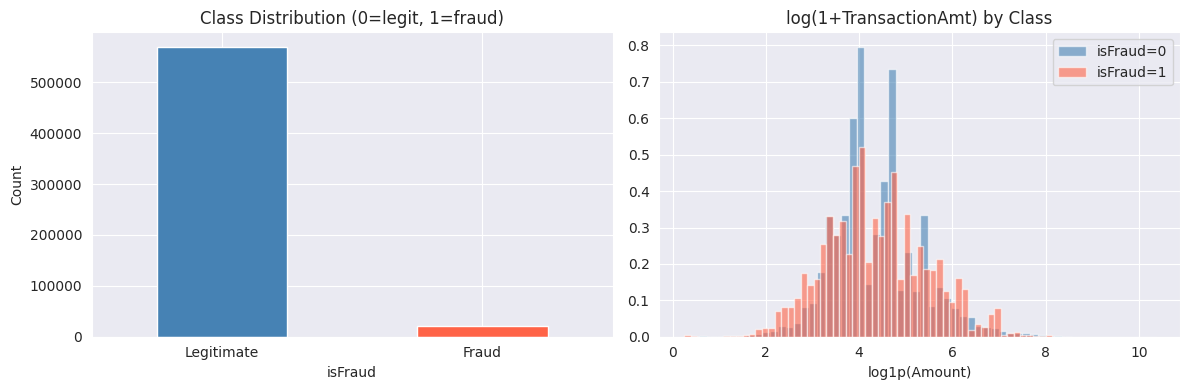

In [4]:
fraud_rate = train['isFraud'].mean()
n_fraud    = train['isFraud'].sum()
n_total    = len(train)
print(f'Fraud rate: {fraud_rate*100:.2f}%  ({n_fraud:,} / {n_total:,})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance bar
train['isFraud'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Class Distribution (0=legit, 1=fraud)')
axes[0].set_xlabel('isFraud')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

# TransactionAmt distribution by class
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = train[train['isFraud'] == label]['TransactionAmt']
    axes[1].hist(np.log1p(subset), bins=60, alpha=0.6,
                 label=f'isFraud={label}', color=color, density=True)
axes[1].set_title('log(1+TransactionAmt) by Class')
axes[1].set_xlabel('log1p(Amount)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/01_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Fraud Rate by Categorical Feature

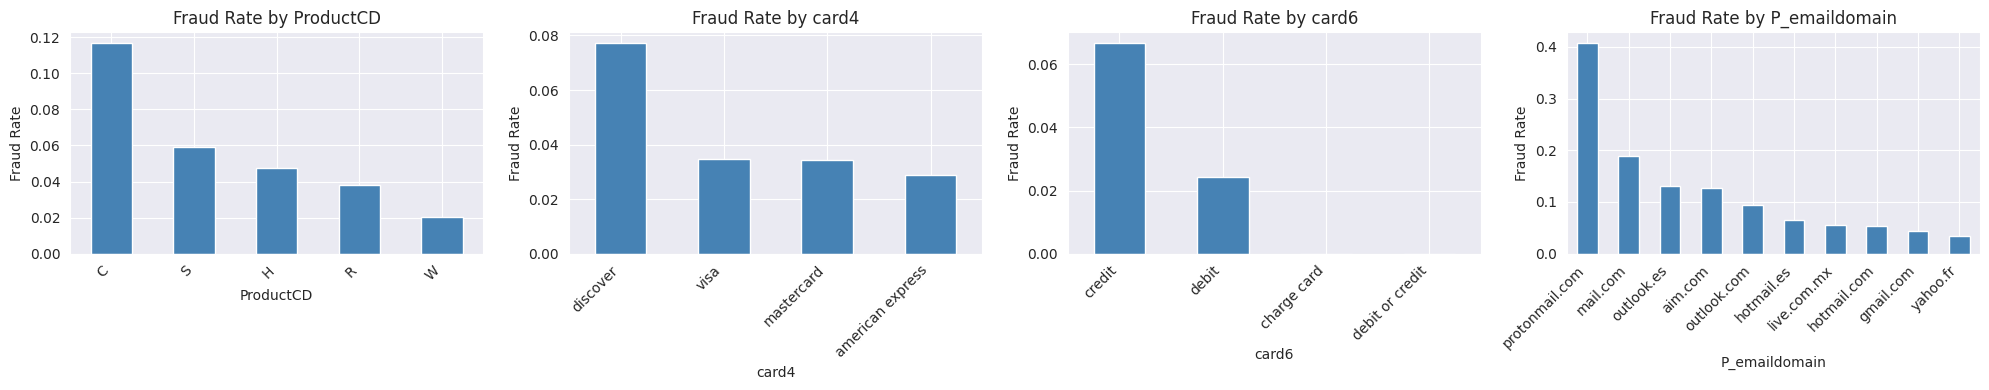

In [5]:
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 4))

for ax, col in zip(axes, cat_cols):
    rates = (train.groupby(col)['isFraud'].mean()
             .sort_values(ascending=False).head(10))
    rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../results/01_fraud_rate_by_cat.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Missing Value Analysis

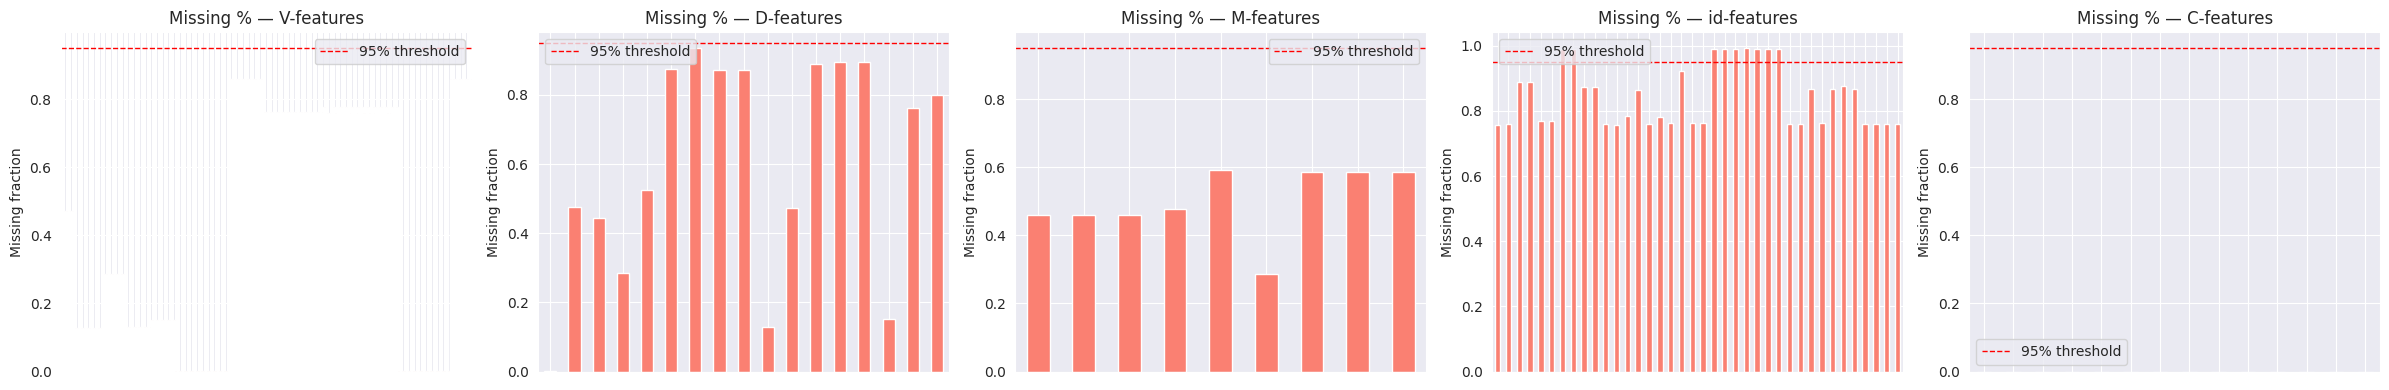

Columns with >95% missing: 9
['id_07', 'id_08', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27'] ...


In [6]:
def missing_pct(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    return df[cols].isnull().mean() if cols else pd.Series(dtype=float)

groups = {'V-features': 'V', 'D-features': 'D', 'M-features': 'M',
          'id-features': 'id_', 'C-features': 'C'}
fig, axes = plt.subplots(1, len(groups), figsize=(24, 4))

for ax, (label, prefix) in zip(axes, groups.items()):
    pct = missing_pct(train, prefix)
    if pct.empty:
        ax.set_visible(False)
        continue
    pct.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
    ax.axhline(0.95, color='red', linestyle='--', linewidth=1, label='95% threshold')
    ax.set_title(f'Missing % — {label}')
    ax.set_ylabel('Missing fraction')
    ax.set_xticklabels([])
    ax.legend()

plt.tight_layout()
plt.savefig('../results/01_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

# Columns to drop (>95% missing in train)
drop_cols = train.columns[train.isnull().mean() > 0.95].tolist()
print(f'Columns with >95% missing: {len(drop_cols)}')
print(drop_cols[:10], '...')

## 6. Temporal Patterns

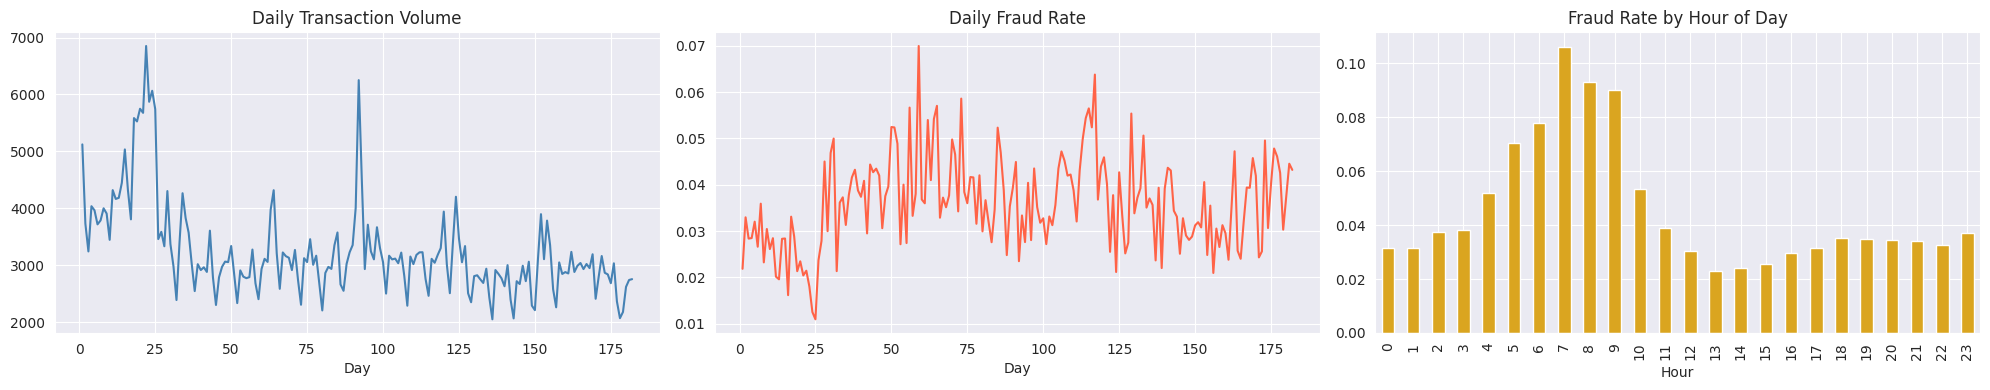

In [7]:
train['day']  = (train['TransactionDT'] / 86400).astype(int)
train['hour'] = ((train['TransactionDT'] % 86400) / 3600).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

train.groupby('day').size().plot(ax=axes[0], color='steelblue')
axes[0].set_title('Daily Transaction Volume')
axes[0].set_xlabel('Day')

train.groupby('day')['isFraud'].mean().plot(ax=axes[1], color='tomato')
axes[1].set_title('Daily Fraud Rate')
axes[1].set_xlabel('Day')

hourly = train.groupby('hour')['isFraud'].mean()
hourly.plot(kind='bar', ax=axes[2], color='goldenrod', edgecolor='white')
axes[2].set_title('Fraud Rate by Hour of Day')
axes[2].set_xlabel('Hour')

plt.tight_layout()
plt.savefig('../results/01_temporal_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

train.drop(columns=['day', 'hour'], inplace=True)

## 7. Summary

- **Fraud rate:** ~3.5% — significant class imbalance → motivates SMOTE in notebook 02
- **Key categorical signals:** card4 (network), card6 (debit/credit), ProductCD
- **High-missing columns:** many V-features and id-features >95% missing → drop in preprocessing
- **Temporal structure:** data spans ~180 days; fraud rate has intra-day patterns → `hour_of_day` is a useful feature
- **Amount distribution:** right-skewed → `log_amount` transform helps linear models (and speeds XGBoost)